In [1]:
IMAGE_PATH = 'Groceries_Invoice.pdf'

In [2]:
!pip install easyocr
!pip install -q -U google-genai
!pip install -q pymupdf

In [3]:
import os
import re
import easyocr
import cv2
import math
import json
import numpy as np

from google import genai

from matplotlib import pyplot as plt
from PIL import Image, ImageDraw
import nltk
from nltk.corpus import words

nltk.download('words')

import difflib
from enum import Enum
from typing import Tuple, Optional, Sequence, List
from dataclasses import dataclass
import pydantic

[nltk_data] Downloading package words to
[nltk_data]     C:\Users\sneha\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


PDF converted successfully: invoice_page_1.png
Image shape: (2977, 2105, 3)
Number of detected lines: 484
Dominant angle detected: 0.00 degrees
Aligned image saved as: aligned.jpg


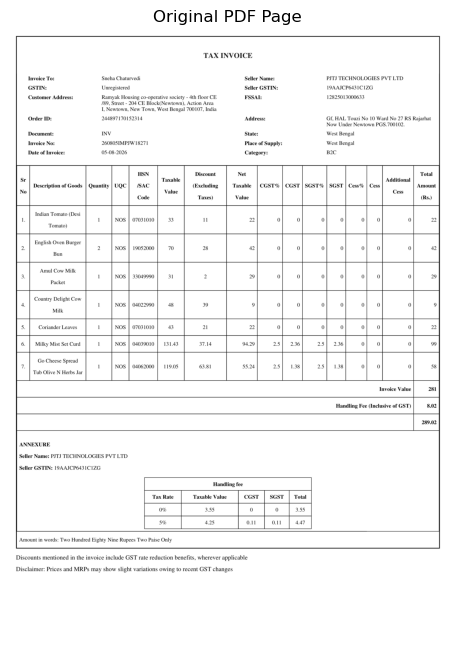

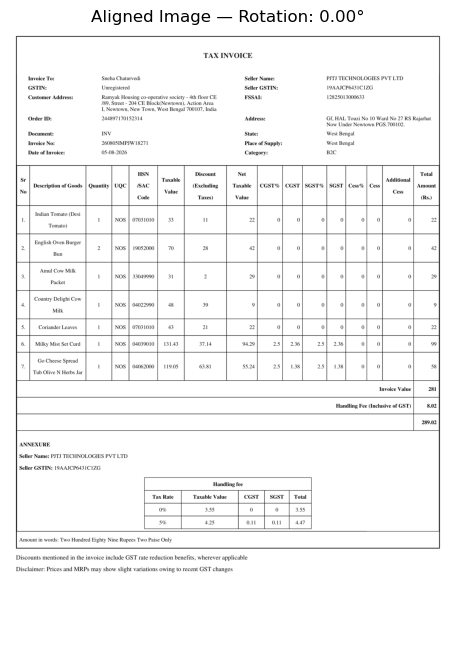

In [4]:
import cv2
import numpy as np
import os
import fitz
from matplotlib import pyplot as plt

IMAGE_PATH = r"Groceries_Invoice.pdf"

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"File not found: {IMAGE_PATH}")
pdf_document = fitz.open(IMAGE_PATH)
page = pdf_document[0]
zoom = 2.5
matrix = fitz.Matrix(zoom, zoom)
pix = page.get_pixmap(
    matrix=matrix,
    alpha=False
)
pdf_image_path = "invoice_page_1.png"
pix.save(pdf_image_path)
pdf_document.close()
print(f"PDF converted successfully: {pdf_image_path}")
image = cv2.imread(pdf_image_path)
if image is None:
    raise ValueError(
        f"OpenCV could not read the converted image: {pdf_image_path}"
    )
print("Image shape:", image.shape)
def rotate_bound(image, angle):
    (h, w) = image.shape[:2]
    center = (w / 2, h / 2)
    M = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )
    cos = abs(M[0, 0])
    sin = abs(M[0, 1])
    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))
    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]
    return cv2.warpAffine(
        image,
        M,
        (new_w, new_h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )
gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)
edges = cv2.Canny(
    gray,
    50,
    150,
    apertureSize=3
)
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=100,
    minLineLength=100,
    maxLineGap=20
)
angles = []
if lines is not None:
    print("Number of detected lines:", len(lines))
    for line in lines:
        line = np.asarray(line).reshape(-1)
        if len(line) < 4:
            continue
        x1, y1, x2, y2 = line[:4]
        angle = np.degrees(
            np.arctan2(
                y2 - y1,
                x2 - x1
            )
        )
        if -45 <= angle <= 45:
            angles.append(angle)
if len(angles) > 0:
    dominant_angle = float(
        np.median(angles)
    )
else:
    dominant_angle = 0.0
print(
    f"Dominant angle detected: {dominant_angle:.2f} degrees"
)
corrected_image = rotate_bound(
    image,
    dominant_angle
)
corrected_image_path = "aligned.jpg"
success = cv2.imwrite(
    corrected_image_path,
    corrected_image
)
if not success:
    raise ValueError(
        "Failed to save aligned image."
    )
print(
    f"Aligned image saved as: {corrected_image_path}"
)
plt.figure(figsize=(15, 8))
plt.imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)
plt.title("Original PDF Page")
plt.axis("off")
plt.show()
plt.figure(figsize=(15, 8))
plt.imshow(
    cv2.cvtColor(corrected_image, cv2.COLOR_BGR2RGB)
)
plt.title(
    f"Aligned Image — Rotation: {dominant_angle:.2f}°"
)
plt.axis("off")
plt.show()

In [5]:
reader = easyocr.Reader(['en'])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
C:\Users\sneha\anaconda3\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


In [6]:
english_words = set(words.words())
def calculate_percentage(text):
    cleaned_string = re.sub(
        r'[^a-zA-Z0-9\s]',
        '',
        text
    )
    words_in_text = cleaned_string.split()
    num_valid_words = sum(
        1
        for word in words_in_text
        if word.lower() in english_words
    )
    total_words = len(words_in_text)
    if total_words == 0:
        return 0
    percentage = (
        num_valid_words / total_words
    ) * 100
    return percentage
def process_image(im_path):
    if not os.path.exists(im_path):
        raise FileNotFoundError(
            f"Image not found: {im_path}"
        )
    result_original = reader.readtext(im_path)
    data_original = result_original
    combined_string_original = " ".join(
        item[1]
        for item in data_original
    )
    percentage_original = calculate_percentage(
        combined_string_original
    )
    im = Image.open(im_path)
    im_flipped = im.transpose(
        Image.FLIP_LEFT_RIGHT
    )
    flipped_path = "flipped_image.jpg"
    im_flipped.save(
        flipped_path
    )
    result_flipped = reader.readtext(
        flipped_path
    )
    data_flipped = result_flipped
    combined_string_flipped = " ".join(
        item[1]
        for item in data_flipped
    )
    percentage_flipped = calculate_percentage(
        combined_string_flipped
    )
    if percentage_original > percentage_flipped:

        final_image = im
        highest_percentage = percentage_original
        flipped = False
    else:
        final_image = im_flipped
        highest_percentage = percentage_flipped
        flipped = True
    return (
        final_image,
        highest_percentage,
        flipped
    )
im_path = "aligned.jpg"
final_image, highest_percentage, flipped = process_image(
    im_path
)
if flipped:
    flip_status = "flipped"
else:
    flip_status = "not flipped"
print(
    f"The image was originally {flip_status}."
)
print(
    f"The raw OCR extract contains "
    f"{highest_percentage:.2f}% actual English words."
)
final_image_path = "final_image.jpg"
final_image.save(
    final_image_path
)
print(
    f"Final image saved as: {final_image_path}"
)

C:\Users\sneha\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\sneha\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


The image was originally not flipped.
The raw OCR extract contains 48.11% actual English words.
Final image saved as: final_image.jpg


In [7]:
final_image = 'final_image.jpg'
result = reader.readtext(final_image)
data = result

C:\Users\sneha\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [8]:
class OCRWord:
    """
    Represents an OCR-detected word with its coordinates,
    confidence, and calculated properties.
    """
    def __init__(self, data: Tuple[List[Tuple[int, int]], str, float]):
        """
        Initialize an OCRWord instance.
        Parameters:
            data: Tuple containing:
                coordinates,
                detected text,
                confidence
        """
        self.name = data[1]
        self.coordinates = data[0]
        self.__confidence = data[2]
    @property
    def center(self) -> Tuple[float, float]:
        """
        Calculate and return the center coordinates.
        """
        x_coords = [
            coord[0] for coord in self.coordinates
        ]
        y_coords = [
            coord[1] for coord in self.coordinates
        ]
        center_x = sum(x_coords) / len(x_coords)
        center_y = sum(y_coords) / len(y_coords)
        return (center_x, center_y)
    @property
    def height(self) -> int:
        """
        Calculate the height of the bounding box.
        """
        y_coords = [
            coord[1] for coord in self.coordinates
        ]
        return max(y_coords) - min(y_coords)
    @property
    def confidence(self) -> float:
        """
        Return OCR confidence.
        """
        return self.__confidence
    def __str__(self) -> str:
        """
        String representation of OCRWord.
        """
        return (
            f"Name: {self.name}\n"
            f"Coordinates: {self.coordinates}\n"
            f"Center: {self.center}\n"
            f"Height: {self.height}\n"
            f"Confidence: {self.confidence}"
        )

In [9]:
data = result
ocr_words = [
    OCRWord(item)
    for item in data
]
for word in ocr_words[:15]:
    print(word)
    print("-----------")

Name: TAX INVOICE
Coordinates: [[np.int32(929), np.int32(106)], [np.int32(1175), np.int32(106)], [np.int32(1175), np.int32(142)], [np.int32(929), np.int32(142)]]
Center: (np.float64(1052.0), np.float64(124.0))
Height: 36
Confidence: 0.9976600270727078
-----------
Name: Invoice To:
Coordinates: [[np.int32(84), np.int32(218)], [np.int32(218), np.int32(218)], [np.int32(218), np.int32(248)], [np.int32(84), np.int32(248)]]
Center: (np.float64(151.0), np.float64(233.0))
Height: 30
Confidence: 0.9997868307458438
-----------
Name: Sneha Chaturvedi
Coordinates: [[np.int32(437), np.int32(218)], [np.int32(632), np.int32(218)], [np.int32(632), np.int32(246)], [np.int32(437), np.int32(246)]]
Center: (np.float64(534.5), np.float64(232.0))
Height: 28
Confidence: 0.8959688635942414
-----------
Name: Seller Name:
Coordinates: [[np.int32(1128), np.int32(218)], [np.int32(1281), np.int32(218)], [np.int32(1281), np.int32(248)], [np.int32(1128), np.int32(248)]]
Center: (np.float64(1204.5), np.float64(233.0)

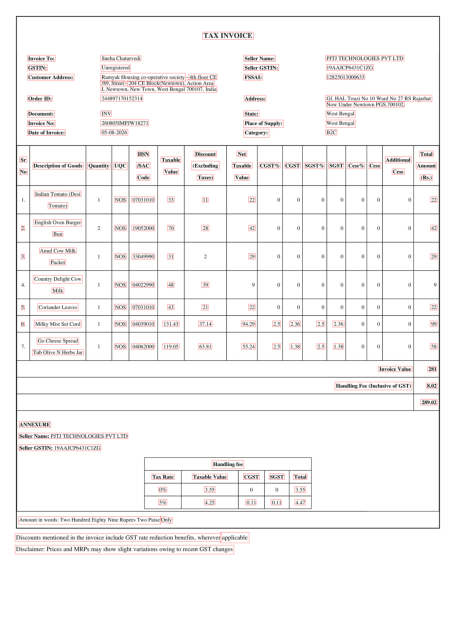

In [10]:
image_path = final_image
original_image = Image.open(image_path)
ocr_data = data
ocr_words = [
    OCRWord(data)
    for data in ocr_data
]
image_with_boxes = original_image.copy()
draw = ImageDraw.Draw(image_with_boxes)
for word in ocr_words:
    flattened_coordinates = [
        coord
        for sublist in word.coordinates
        for coord in sublist
    ]
    draw.polygon(
        flattened_coordinates,
        outline="red"
    )
plt.figure(figsize=(8, 8))
plt.imshow(image_with_boxes)
plt.axis('off')
plt.show()

In [11]:
word_data_list = data
ocr_words = [
    OCRWord(data)
    for data in word_data_list
]
sorted_words = sorted(
    ocr_words,
    key=lambda word: word.confidence
)
for word in sorted_words[:5]:
    print(
        f"Word: {word.name}, "
        f"Confidence: {word.confidence}"
    )

Word: 1, Newtown, New Town; West Bengal 700107, India, Confidence: 0.4579342530391418
Word: 281, Confidence: 0.5321689248085022
Word: Gf, HAL Touzi No 10 Ward No 27 RS Rajarhat, Confidence: 0.572714412359356
Word: Tax Rate, Confidence: 0.5849370007981178
Word: 2.36, Confidence: 0.5899837780153907


In [12]:
image_path = 'invoice_page_1.png'
original_image = Image.open(image_path)
cutout_folder = 'cutout_images_folder'
os.makedirs(cutout_folder, exist_ok=True)
for index, word in enumerate(ocr_words):
    cleaned_word_name = re.sub(
        r'[^a-zA-Z]',
        '',
        word.name
    )
    x_coords = [
        coord[0]
        for coord in word.coordinates
    ]
    y_coords = [
        coord[1]
        for coord in word.coordinates
    ]
    left = min(x_coords)
    upper = min(y_coords)
    right = max(x_coords)
    lower = max(y_coords)
    cutout_image = original_image.crop(
        (left, upper, right, lower)
    )
    cutout_filename = (
        f'{index}_{cleaned_word_name}.jpg'
    )
    cutout_image_path = os.path.join(
        cutout_folder,
        cutout_filename
    )
    cutout_image.save(
        cutout_image_path
    )
image_name, image_extension = os.path.splitext(
    os.path.basename(image_path)
)
output_image_path = (
    f'{image_name}_with_boxes{image_extension}'
)
image_with_boxes.save(
    output_image_path
)
print(
    "Bounding box image saved:",
    output_image_path
)
print(
    "Cutout images saved in:",
    cutout_folder
)

Bounding box image saved: invoice_page_1_with_boxes.png
Cutout images saved in: cutout_images_folder


In [13]:
ocr_words_list = [
    OCRWord(data)
    for data in result
]
word_names = [
    word.name
    for word in ocr_words_list
]
print(word_names)

['TAX INVOICE', 'Invoice To:', 'Sneha Chaturvedi', 'Seller Name:', 'PJTJ TECHNOLOGIES PVT LTD', 'GSTIN:', 'Unregistered', 'Seller GSTIN:', '19AAJCP643ICIZG', 'Customer Address:', 'Ramyak Housing CO-operative society', '4th floor CE', 'FSSAI:', '12825013000633', '/89, Street', '204 CE Block(Newtown) , Action Area', '1, Newtown, New Town; West Bengal 700107, India', 'Order ID:', '244897170152314', 'Address:', 'Gf, HAL Touzi No 10 Ward No 27 RS Rajarhat', 'Now Under Newtown PGS.700102', 'Document:', 'INV', 'State:', 'West Bengal', 'Invoice No:', '260805IMPJW18271', 'Place of Supply:', 'West Bengal', 'Date of Invoice:', '05-08-2026', 'Category:', 'BZC', 'HSN', 'Discount', 'Net', 'Total', 'Sr', 'Taxable', 'Additional', 'Description of Goods', 'Quantity', 'UQC', 'ISAC', '(Excluding', 'Taxable', 'CGST%', 'CGST', 'SGST %', 'SGST', 'Cess %', 'Cess', 'Amount', 'No', 'Value', 'Cess', 'Code', 'Taxes)', 'Value', '(Rs.)', 'Indian Tomato (Desi', 'NOS', '07031010', '33', '11', '22', '22', 'Tomato)', '

In [14]:
def calculate_similarity(alias, text):
    return difflib.SequenceMatcher(
        None,
        alias.lower(),
        text.lower()
    ).ratio()
def find_best_match(key, text_list):
    best_match = max(
        text_list,
        key=lambda text: calculate_similarity(
            key,
            text
        )
    )
    return (
        best_match
        if calculate_similarity(key, best_match) > 0
        else None
    )
def extract_field_value(aliases, text_list):
    for alias in aliases:
        for text in text_list:
            if re.search(
                r'\b{}\b'.format(alias),
                text,
                re.IGNORECASE
            ):
                return text
    return None
def extract_invoice_information(
    text_list,
    similarity_threshold=0
):
    keys = {
        'Invoice number': {
            'invoice no',
            'invoice no.',
            'invoice number',
            'serial no. of invoice'
        },
        'Invoice date': {
            'dated',
            'invoice date',
            'date of invoice'
        },
        'GST number': {
            'GSTIN/UIN',
            'GST Number',
            'gstin',
            'GSTINIUIN'
        },
        'Seller name': {
            'consignee'
        },
        'Seller address': {
            'consignee'
        },
        'Delivery address': {
            'consignee',
            'buyer',
            'delivery address',
            'ship to'
        },
        'Buyer Name': {
            'consignee',
            'buyer',
            'customer'
        },
        'Buyer address': {
            'consignee',
            'buyer',
            'buyer address'
        },
        'Description of Goods': {
            'Description of Goods',
            'Item Descrption',
            'Description',
            'Product / Service'
        },
        'Price': {
            'price',
            'rate',
            'rale'
        },
        'Quantity': {
            'quantity',
            'qty'
        },
        'Item Codes': {
            'item codes',
            'hsn/sac',
            'hsn',
            'sac',
            'HSNISAC'
        },
        'Discount': {
            'discount',
            'disc'
        },
        'Taxation: Central Tax': {
            'cgst',
            'central tax'
        },
        'Taxation: State Tax': {
            'sgst',
            'state tax',
            'utisgst'
        },
        'Total invoice amount': {
            'total'
        },
        'Total tax amount': {
            'tax amount'
        },
        'PO number': {
            'po number',
            'purchase order no',
            'po no',
            'po'
        }
    }
    extracted_info = {}
    for field, aliases in keys.items():
        best_alias = None
        best_similarity = 0
        for alias in aliases:
            value = extract_field_value(
                [alias],
                text_list
            )
            if value:
                similarity = calculate_similarity(
                    alias,
                    value
                )
                if similarity > best_similarity:
                    best_similarity = similarity
                    best_alias = alias
        if (
            best_alias
            and best_similarity >= similarity_threshold
        ):
            extracted_info[field] = (
                extract_field_value(
                    [best_alias],
                    text_list
                )
            )
        else:
            extracted_info[field] = None
    return extracted_info
ocr_output = word_names
extracted_info = extract_invoice_information(
    ocr_output
)
for field, value in extracted_info.items():
    print(
        f"{field}: {value}"
    )

Invoice number: Invoice No:
Invoice date: Date of Invoice:
GST number: GSTIN:
Seller name: None
Seller address: None
Delivery address: None
Buyer Name: Customer Address:
Buyer address: None
Description of Goods: Description of Goods
Price: Tax Rate
Quantity: Quantity
Item Codes: HSN
Discount: Discount
Taxation: Central Tax: CGST%
Taxation: State Tax: SGST %
Total invoice amount: Total
Total tax amount: None
PO number: None


In [15]:
def find_closest_neighbors(
    target_word,
    data,
    confidence_cutoff=0.3
):
    ocr_words = [
        OCRWord(datum)
        for datum in data
        if datum[2] >= confidence_cutoff
    ]
    target_ocr_word = None
    for ocr_word in ocr_words:
        if ocr_word.name == target_word:
            target_ocr_word = ocr_word
            break
    if target_ocr_word is None:
        return []
    neighbors = []
    right_tolerance = 50
    below_tolerance = 20
    for other_ocr_word in ocr_words:
        if target_word != other_ocr_word.name:
            other_x, other_y = (
                other_ocr_word.coordinates[0]
            )
            target_x, target_y = (
                target_ocr_word.coordinates[0]
            )
            distance = math.sqrt(
                (other_x - target_x) ** 2
                +
                (other_y - target_y) ** 2
            )
            if (
                other_x >= target_x
                and
                abs(other_y - target_y)
                <= below_tolerance
            ):
                neighbors.append(
                    (
                        other_ocr_word.name,
                        distance,
                        'exactly_right'
                    )
                )
            elif (
                other_y >= target_y
                and
                abs(other_x - target_x)
                <= right_tolerance
            ):
                neighbors.append(
                    (
                        other_ocr_word.name,
                        distance,
                        'exactly_below'
                    )
                )
            elif other_y >= target_y:
                neighbors.append(
                    (
                        other_ocr_word.name,
                        distance,
                        'below'
                    )
                )
            else:
                neighbors.append(
                    (
                        other_ocr_word.name,
                        distance,
                        'other'
                    )
                )
    neighbors.sort(
        key=lambda x: x[1]
    )
    right_neighbors = [
        neighbor[0]
        for neighbor in neighbors
        if neighbor[2] == 'exactly_right'
    ][:3]
    below_neighbors = [
        neighbor[0]
        for neighbor in neighbors
        if neighbor[2] == 'exactly_below'
    ][:3]
    right_below_neighbors = [
        neighbor[0]
        for neighbor in neighbors
        if neighbor[2] == 'below'
    ][:3]
    remaining_neighbors = [
        neighbor[0]
        for neighbor in neighbors
        if neighbor[0]
        not in (
            right_neighbors
            +
            below_neighbors
            +
            right_below_neighbors
        )
    ][:3]
    return (
        right_neighbors
        +
        below_neighbors
        +
        right_below_neighbors
    )

In [16]:
for key in extracted_info:
    neighboring_words = extracted_info[key]
    closest_neighbors = find_closest_neighbors(
        extracted_info[key],
        data
    )
    closest_neighbors_str = ', '.join(
        map(str, closest_neighbors)
    )
    formatted_string = ", ".join(
        f'"{item}"'
        for item in closest_neighbors
    )
    if neighboring_words is None:
        continue
    else:
        neighboring_words_str = ''.join(
            [
                f'{word}'
                for word in neighboring_words
            ]
        )
        neighboring_words_str = (
            '"' + neighboring_words_str + '"'
        )
        neighboring_words_str += ','
    print(
        'Key:',
        key
    )
    print(
        'Neighboring Words:',
        neighboring_words_str,
        end=" "
    )
    print(
        formatted_string
    )

Key: Invoice number
Neighboring Words: "Invoice No:", "260805IMPJW18271", "Place of Supply:", "West Bengal", "Date of Invoice:", "Sr", "Description of Goods", "Quantity", "05-08-2026", "Tomato)"
Key: Invoice date
Neighboring Words: "Date of Invoice:", "05-08-2026", "Category:", "BZC", "Sr", "Description of Goods", "No", "Quantity", "Tomato)", "UQC"
Key: GST number
Neighboring Words: "GSTIN:", "Unregistered", "Seller GSTIN:", "19AAJCP643ICIZG", "Customer Address:", "Order ID:", "Document:", "Ramyak Housing CO-operative society", "/89, Street", "1, Newtown, New Town; West Bengal 700107, India"
Key: Buyer Name
Neighboring Words: "Customer Address:", "Ramyak Housing CO-operative society", "4th floor CE", "FSSAI:", "Order ID:", "Document:", "Invoice No:", "/89, Street", "1, Newtown, New Town; West Bengal 700107, India", "244897170152314"
Key: Description of Goods
Neighboring Words: "Description of Goods", "Quantity", "UQC", "ISAC", "Indian Tomato (Desi", "English Oven Burger", "Amul Cow Mil

In [17]:
from google import genai
GEMINI_API_KEY = YOUR_API_KEY
client = genai.Client(
    api_key=GEMINI_API_KEY
)
MODEL_NAME = "gemini-2.5-flash"
print("Gemini client initialized successfully.")

Gemini client initialized successfully.


In [18]:
def gemini_chat_completion(prompt: str):
    """
    Generate a JSON response using the Google Gemini API.
    """
    try:
        response = client.models.generate_content(
            model=MODEL_NAME,
            contents=prompt,
            config={
                "system_instruction": (
                    "You are an invoice data extraction assistant. "
                    "Extract the requested fields from the OCR data. "
                    "Return ONLY valid JSON. "
                    "Do not add explanations or markdown. "
                    "Do not invent values. "
                    "If a value cannot be determined, return null."
                ),
                "temperature": 0,
                "max_output_tokens": 9000,
                "response_mime_type": "application/json"
            }
        )
        return response
    except Exception as e:
        print(f"Gemini API error: {e}")
        return None

In [19]:
def get_gemini_response_text(prompt: str):
    """
    Call Gemini and return only the generated text.
    """
    response = gemini_chat_completion(
        prompt
    )
    if response is None:
        return None
    return response.text

In [20]:
stored_results = {}
for key in extracted_info:
    neighboring_words = extracted_info[key]
    closest_neighbors = find_closest_neighbors(
        extracted_info[key],
        data
    )
    if neighboring_words is None:
        continue
    else:
        neighboring_words_str = ''.join(
            neighboring_words
        )
        neighboring_words_str = (
            '"' +
            neighboring_words_str +
            '"'
        )
    closest_neighbors_str = ', '.join(
        map(str, closest_neighbors)
    )
    formatted_string = ', '.join(
        f'"{item}"'
        for item in closest_neighbors
    )
    stored_results[key] = {
        'Neighboring Words':
            f'{neighboring_words_str}, '
            f'{formatted_string}'
    }

In [21]:
import json
full_ocr_text = " ".join(
    word.name for word in ocr_words
)
invoice_extraction_prompt = f"""
You are an invoice OCR data extraction system.
Your task is to extract structured information from the invoice
using the COMPLETE OCR TEXT provided below.

IMPORTANT RULES:
1. Use the COMPLETE OCR TEXT as the primary source.
2. The invoice contains a table with multiple line items.
3. Extract EVERY line item visible in the OCR.
4. Do NOT stop after the first 3 products.
5. Preserve the order of the line items.
6. Do NOT guess values.
7. If a value is genuinely not present, use null.
8. Do not confuse Buyer Name with Seller Name.
9. The text following "Invoice To:" is the Buyer Name.
10. The text following "Seller Name:" is the Seller Name.
11. The GSTIN following "Seller GSTIN:" is the Seller GSTIN.
12. Extract the table columns according to their headings.
13. Each row must have its own Quantity, HSN/SAC Code,
    Taxable Value, Discount, Net Taxable Value, taxes,
    and Total Amount.
14. Do not use values from another row.
15. Return ONLY valid JSON.
16. Do not return markdown.
17. Do not return explanations.

EXPECTED JSON STRUCTURE:
{{
  "Invoice number": null,
  "Invoice date": null,
  "GST number": null,
  "Buyer Name": null,
  "Buyer Address": null,
  "Seller Name": null,
  "Seller GSTIN": null,
  "Seller Address": null,
  "Place of Supply": null,
  "Items": [
    {{
      "Description of Goods": null,
      "Quantity": null,
      "UQC": null,
      "HSN/SAC Code": null,
      "Taxable Value": null,
      "Discount": null,
      "Net Taxable Value": null,
      "CGST%": null,
      "CGST": null,
      "SGST%": null,
      "SGST": null,
      "Cess%": null,
      "Cess": null,
      "Additional Cess": null,
      "Total Amount": null
    }}
  ],
  "Invoice Value": null,
  "Handling Fee": null,
  "Final Amount": null
}}
=========================================================
COMPLETE OCR TEXT
=========================================================
{full_ocr_text}
=========================================================
NEIGHBORING OCR INFORMATION
=========================================================
{json.dumps(stored_results, indent=2, ensure_ascii=False)}
=========================================================
FINAL INSTRUCTIONS:

Extract all information that can be reliably identified.

The invoice table must be completely extracted.

Do NOT return only the first few products.

If a field is not available, return null.

Return ONLY valid JSON.
"""
print(invoice_extraction_prompt)


You are an invoice OCR data extraction system.
Your task is to extract structured information from the invoice
using the COMPLETE OCR TEXT provided below.

IMPORTANT RULES:
1. Use the COMPLETE OCR TEXT as the primary source.
2. The invoice contains a table with multiple line items.
3. Extract EVERY line item visible in the OCR.
4. Do NOT stop after the first 3 products.
5. Preserve the order of the line items.
6. Do NOT guess values.
7. If a value is genuinely not present, use null.
8. Do not confuse Buyer Name with Seller Name.
9. The text following "Invoice To:" is the Buyer Name.
10. The text following "Seller Name:" is the Seller Name.
11. The GSTIN following "Seller GSTIN:" is the Seller GSTIN.
12. Extract the table columns according to their headings.
13. Each row must have its own Quantity, HSN/SAC Code,
    Taxable Value, Discount, Net Taxable Value, taxes,
    and Total Amount.
14. Do not use values from another row.
15. Return ONLY valid JSON.
16. Do not return markdown.
17.

In [22]:
content = get_gemini_response_text(
    invoice_extraction_prompt
)
print("========== GEMINI RESPONSE ==========")
if content is not None:
    print(content)
else:
    print("No response was returned by Gemini.")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


========== GEMINI RESPONSE ==========
{
  "Invoice number": "260805IMPJW18271",
  "Invoice date": "05-08-2026",
  "GST number": "Unregistered",
  "Buyer Name": "Sneha Chaturvedi",
  "Buyer Address": "Ramyak Housing CO-operative society 4th floor CE /89, Street 204 CE Block(Newtown) , Action Area 1, Newtown, New Town; West Bengal 700107, India",
  "Seller Name": "PJTJ TECHNOLOGIES PVT LTD",
  "Seller GSTIN": "19AAJCP643ICIZG",
  "Seller Address": "Gf, HAL Touzi No 10 Ward No 27 RS Rajarhat Now Under Newtown PGS.700102",
  "Place of Supply": "West Bengal",
  "Items": [
    {
      "Description of Goods": "Indian Tomato (Desi Tomato)",
      "Quantity": 3,
      "UQC": "NOS",
      "HSN/SAC Code": "07031010",
      "Taxable Value": 33.00,
      "Discount": 11.00,
      "Net Taxable Value": 22.00,
      "CGST%": null,
      "CGST": null,
      "SGST%": null,
      "SGST": null,
      "Cess%": null,
      "Cess": null,
      "Additional Cess": null,
      "Total Amount": 22.00
    },
    {
